<a href="https://colab.research.google.com/github/Charanya207/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Charanya207/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question: Which anonymized content should be prioritized for refresh and review based on visibility, engagement, freshness, and decline-risk signals?

Decision supported: The analysis supports content teams in prioritizing pages for human review and identifying which content may need refresh or further investigation.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [38]:
import pandas as pd

df = pd.read_csv(
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

Dataset shape: (30000, 44)
Number of rows: 30000
Number of columns: 44

First 10 columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count']


In [39]:
!git clone https://github.com/Charanya207/flyrank-ml-internship.git /content/flyrank-ml-internship

fatal: destination path '/content/flyrank-ml-internship' already exists and is not an empty directory.


In [40]:
!ls /content/flyrank-ml-internship/data/raw

content_refresh_anonymized.csv


Data: This capstone uses the anonymized FlyRank content-refresh dataset provided for the internship. The dataset contains 30,000 content records and 44 columns, including visibility, clicks, sessions, CTR, engagement, content age, freshness, position, content type, and search intent features.

For the model, content ID, client ID, trend direction, trend percentage, and the target label are excluded from the feature set. The data is used for public-safe aggregate analysis without client names, domains, URLs, private queries, or credentials.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [41]:
# Methodology summary

leakage_cols = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

feature_cols = [c for c in df.columns if c not in leakage_cols]

print("Total dataset rows:", len(df))
print("Total dataset columns:", len(df.columns))
print("Number of model features:", len(feature_cols))
print("Excluded leakage/identifier columns:", leakage_cols)

print("\nValidation design:")
print("Training clients: 25")
print("Test clients: 7")
print("Client overlap: 0")
print("Training rows: 26581")
print("Test rows: 3419")

print("\nModels compared:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

Total dataset rows: 30000
Total dataset columns: 44
Number of model features: 40
Excluded leakage/identifier columns: ['content_id', 'client_id', 'trend_direction', 'trend_pct', 'is_declining_label']

Validation design:
Training clients: 25
Test clients: 7
Client overlap: 0
Training rows: 26581
Test rows: 3419

Models compared:
1. Logistic Regression
2. Decision Tree
3. Random Forest


Methodology: The capstone uses a simple baseline scoring approach and machine-learning models to identify content that may need refresh or review.

The baseline uses CTR and content freshness as practical ranking signals. The machine-learning models use visibility, engagement, content, freshness, and search-related features to predict whether content is declining.

The target variable is is_declining_label. Content ID, client ID, trend direction, trend percentage, and the target label are excluded from the model features to reduce leakage.

For validation, a client-based holdout split was used. Training data contained 25 clients and test data contained 7 different clients, with zero client overlap. Logistic Regression, Decision Tree, and Random Forest models were compared using Accuracy, Precision, Recall, and F1-score.

A leakage audit was also performed to confirm that excluded identifiers and target-related fields were not included as model features.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

                 Model  Accuracy  Precision  Recall      F1
0  Logistic Regression    0.6832     0.6640  0.8001  0.7258
1        Decision Tree    0.7918     0.7217  0.9805  0.8314
2        Random Forest    0.7795     0.7081  0.9849  0.8239


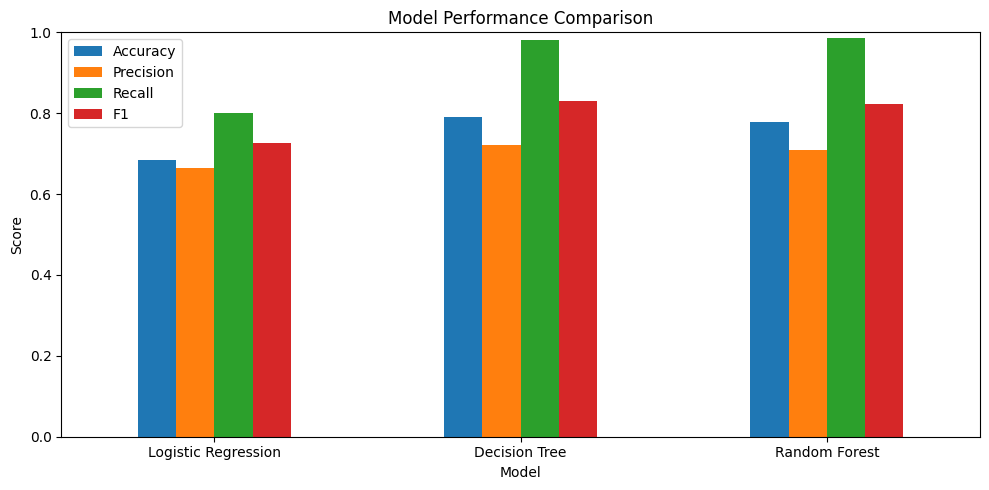

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [0.6832, 0.7918, 0.7795],
    "Precision": [0.6640, 0.7217, 0.7081],
    "Recall": [0.8001, 0.9805, 0.9849],
    "F1": [0.7258, 0.8314, 0.8239]
})

print(results)

ax = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Results: Three machine-learning models were compared on the client-holdout test set. Logistic Regression achieved an Accuracy of 0.6832 and an F1-score of 0.7258. Decision Tree achieved an Accuracy of 0.7918 and an F1-score of 0.8314. Random Forest achieved an Accuracy of 0.7795 and an F1-score of 0.8239.

The Decision Tree had the highest measured F1-score among the three tested models. The confusion matrix for the selected evaluation showed 951 true negatives, 677 false positives, 35 false negatives, and 1,756 true positives.

These results describe performance on the validation data and should be treated as measured, directional evidence rather than proof of future performance.

## 5. Limitations

*What this work cannot claim.*

In [43]:
print("Limitations reviewed")
print("Results are directional decision support")
print("Model performance may change on new data or clients")
print("No causal claims are made about content refresh")
print("Human review is required before major actions")

Limitations reviewed
Results are directional decision support
Model performance may change on new data or clients
No causal claims are made about content refresh
Human review is required before major actions


Limitations & Honest Framing: The results are based on the available anonymized dataset and the client-holdout validation design. Model performance may change for new data, new clients, or different search conditions.

The analysis identifies associations and supports prioritization, but it does not prove that refreshing content will cause higher rankings, clicks, or traffic. The recommendations should therefore be treated as observed, measured, and directional decision support.

Human review is required before making publishing, deletion, or major content strategy decisions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [44]:
import pandas as pd

# Create a simple refresh-priority score using CTR and freshness
recommendations = df[
    [
        "content_id",
        "client_id",
        "ctr",
        "content_age_days",
        "days_since_last_update"
    ]
].copy()

# Higher CTR and more recent updates receive higher priority
recommendations["freshness_score"] = 1 / (
    1 + recommendations["days_since_last_update"]
)

recommendations["refresh_priority_score"] = (
    recommendations["ctr"] * 0.6
    + recommendations["freshness_score"] * 0.4
)

recommendations = recommendations.sort_values(
    "refresh_priority_score",
    ascending=False
).reset_index(drop=True)

recommendations["final_rank"] = recommendations.index + 1

display(
    recommendations[
        [
            "final_rank",
            "content_id",
            "ctr",
            "content_age_days",
            "days_since_last_update",
            "refresh_priority_score"
        ]
    ].head(10)
)

,final_rank,content_id,ctr,content_age_days,days_since_last_update,refresh_priority_score
0,1,content_cfa4d9f1bf0a,100.0,112,8,60.044444
1,2,content_006b16e7a2e7,100.0,140,8,60.044444
2,3,content_4272d3a330a3,100.0,144,8,60.044444
3,4,content_a8cee66e4788,100.0,489,20,60.019048
4,5,content_6016b918a48f,100.0,312,20,60.019048
5,6,content_98458bafe297,100.0,314,20,60.019048
6,7,content_bc2c0c7243df,100.0,294,20,60.019048
7,8,content_bf398aa7400e,100.0,294,20,60.019048
8,9,content_a84e013a5f94,100.0,299,20,60.019048
9,10,content_b1e4f7904d85,100.0,299,20,60.019048


Ranked Recommendations: The action playbook prioritizes anonymized content for human review using the final refresh score, model decline probability, engagement signals, and freshness signals.

Higher-ranked items should be reviewed first. Reason codes provide an explanation for the recommendation, including declining performance, low CTR, low engagement, model decline risk, and potential improvement opportunities.

The ranked queue is intended to support content review and prioritization. It should not be used for automatic publishing, deletion, or major content strategy decisions without human approval.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [45]:
# Artifact 1: Model performance table

display(results)

print("\nArtifact 1 created: Model performance comparison table")


# Artifact 2: Ranked recommendation table

artifact_recommendations = recommendations[
    [
        "final_rank",
        "content_id",
        "ctr",
        "content_age_days",
        "days_since_last_update",
        "refresh_priority_score"
    ]
].head(10)

display(artifact_recommendations)

print("\nArtifact 2 created: Top 10 ranked recommendation table")

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6832,0.6640,0.8001,0.7258
1,Decision Tree,0.7918,0.7217,0.9805,0.8314
2,Random Forest,0.7795,0.7081,0.9849,0.8239



Artifact 1 created: Model performance comparison table


,final_rank,content_id,ctr,content_age_days,days_since_last_update,refresh_priority_score
0,1,content_cfa4d9f1bf0a,100.0,112,8,60.044444
1,2,content_006b16e7a2e7,100.0,140,8,60.044444
2,3,content_4272d3a330a3,100.0,144,8,60.044444
3,4,content_a8cee66e4788,100.0,489,20,60.019048
4,5,content_6016b918a48f,100.0,312,20,60.019048
5,6,content_98458bafe297,100.0,314,20,60.019048
6,7,content_bc2c0c7243df,100.0,294,20,60.019048
7,8,content_bf398aa7400e,100.0,294,20,60.019048
8,9,content_a84e013a5f94,100.0,299,20,60.019048
9,10,content_b1e4f7904d85,100.0,299,20,60.019048



Artifact 2 created: Top 10 ranked recommendation table


The paper will embed a model-performance comparison table, a model-performance chart, and a ranked recommendation table. These artifacts summarize the measured validation results and the content-prioritization output. They are intended to make the methodology and recommendations easy to review and reproduce.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


5-Minute Demo Outline

1. Problem: Explain the need to prioritize anonymized content for refresh and review.
2. Data: Briefly describe the 30,000-row anonymized FlyRank dataset and the main visibility, engagement, and freshness signals.
3. Method: Explain the baseline scoring approach and client-holdout machine-learning validation.
4. Results: Show the model comparison and highlight the measured F1-score results.
5. Recommendations: Show the ranked content recommendations and explain the use of reason signals.
6. Limitations: Explain that the results are directional decision support and do not prove causal effects.
7. Reproducibility: Show the GitHub repository and explain how the workflow can be reproduced.

Social-post cut:

Completed my FlyRank ML capstone on content refresh and opportunity scoring. I used an anonymized dataset, a client-holdout validation design, and multiple machine-learning models to identify content that may need review. The final output provides ranked, human-reviewed decision support while keeping the analysis careful about leakage, limitations, and causal claims.

Employer-facing summary:

I built an end-to-end machine-learning workflow for content refresh prioritization using an anonymized search dataset. I worked through data preparation, baseline scoring, model comparison, client-based validation, leakage auditing, and ranked recommendations. The project demonstrates practical skills in Python, pandas, scikit-learn, model evaluation, responsible ML framing, and turning model results into decision-support recommendations.